In [13]:
# --- Setup & Imports ---
from fastai.vision.all import *
from pathlib import Path

# Define project paths relative to the notebook
# This ensures the code works regardless of absolute system paths
project_root = Path('..')
data_path = project_root / 'data' / 'processed'
model_dir = project_root / 'models'

# Ensure the models directory exists before we try to save anything there
model_dir.mkdir(exist_ok=True)

print(f"Data Path: {data_path.resolve()}")
print(f"Model Path: {model_dir.resolve()}")

Data Path: /home/varfo/PycharmProjects/diatom-classifier/data/processed
Model Path: /home/varfo/PycharmProjects/diatom-classifier/models


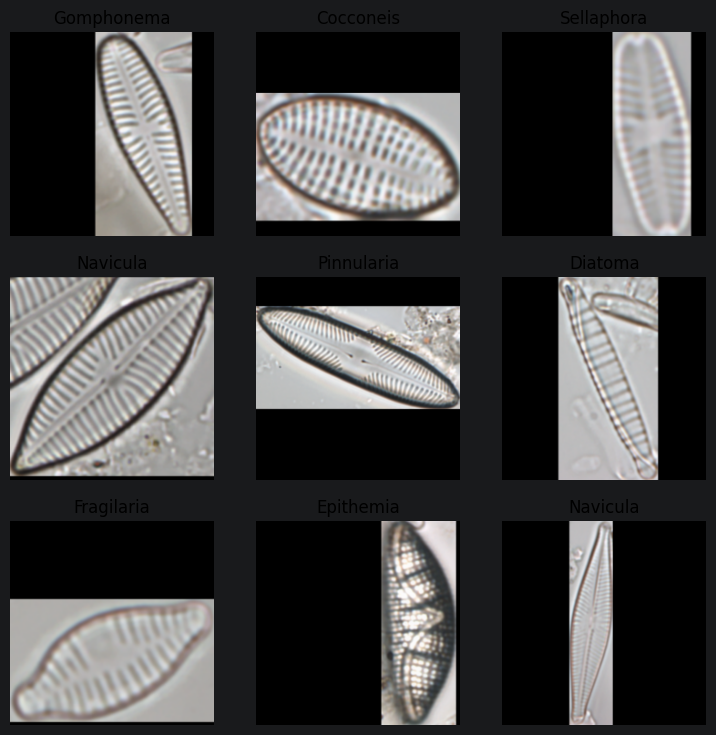

In [14]:
# --- DataBlock Definition ---
# We use PadMode.Zeros to ensure diatoms maintain their true shape (aspect ratio)
# without being stretched or cropped, which is critical for biological classification.

diatom_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # 20% validation set
    get_y=parent_label,                              # Use folder name as Genus label
    item_tfms=Resize(224, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros)
)

# Load data into Fastai DataLoaders
dls = diatom_block.dataloaders(data_path, bs=32)

# Verify the batch visually
dls.show_batch(max_n=9)

In [15]:
# --- Model Training ---
# Initialize a pre-trained ResNet18 model for our baseline test.
learn = vision_learner(dls, resnet18, metrics=accuracy)

# Fine-tune for 2 epochs.
# Epoch 0 trains the custom head, Epochs 1+ train the whole network.
learn.fine_tune(2)

epoch,train_loss,valid_loss,accuracy,time
0,2.593271,0.746912,0.793388,00:53


epoch,train_loss,valid_loss,accuracy,time
0,0.806909,0.359549,0.890909,01:07
1,0.418805,0.265657,0.912397,01:07


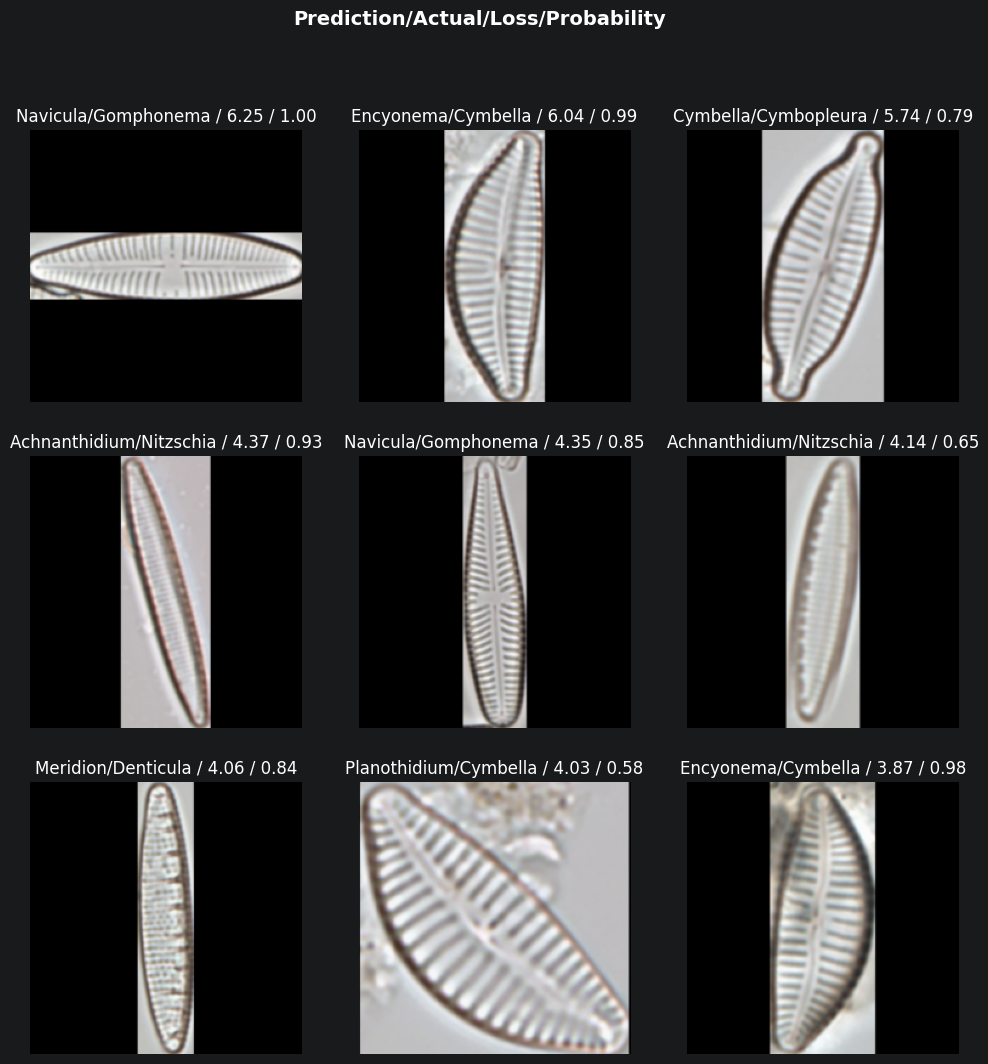

In [16]:
# --- Model Evaluation ---
# Generate interpretation object to understand model failures
interp = ClassificationInterpretation.from_learner(learn)

# View the most confident incorrect predictions
interp.plot_top_losses(9, figsize=(12, 12))

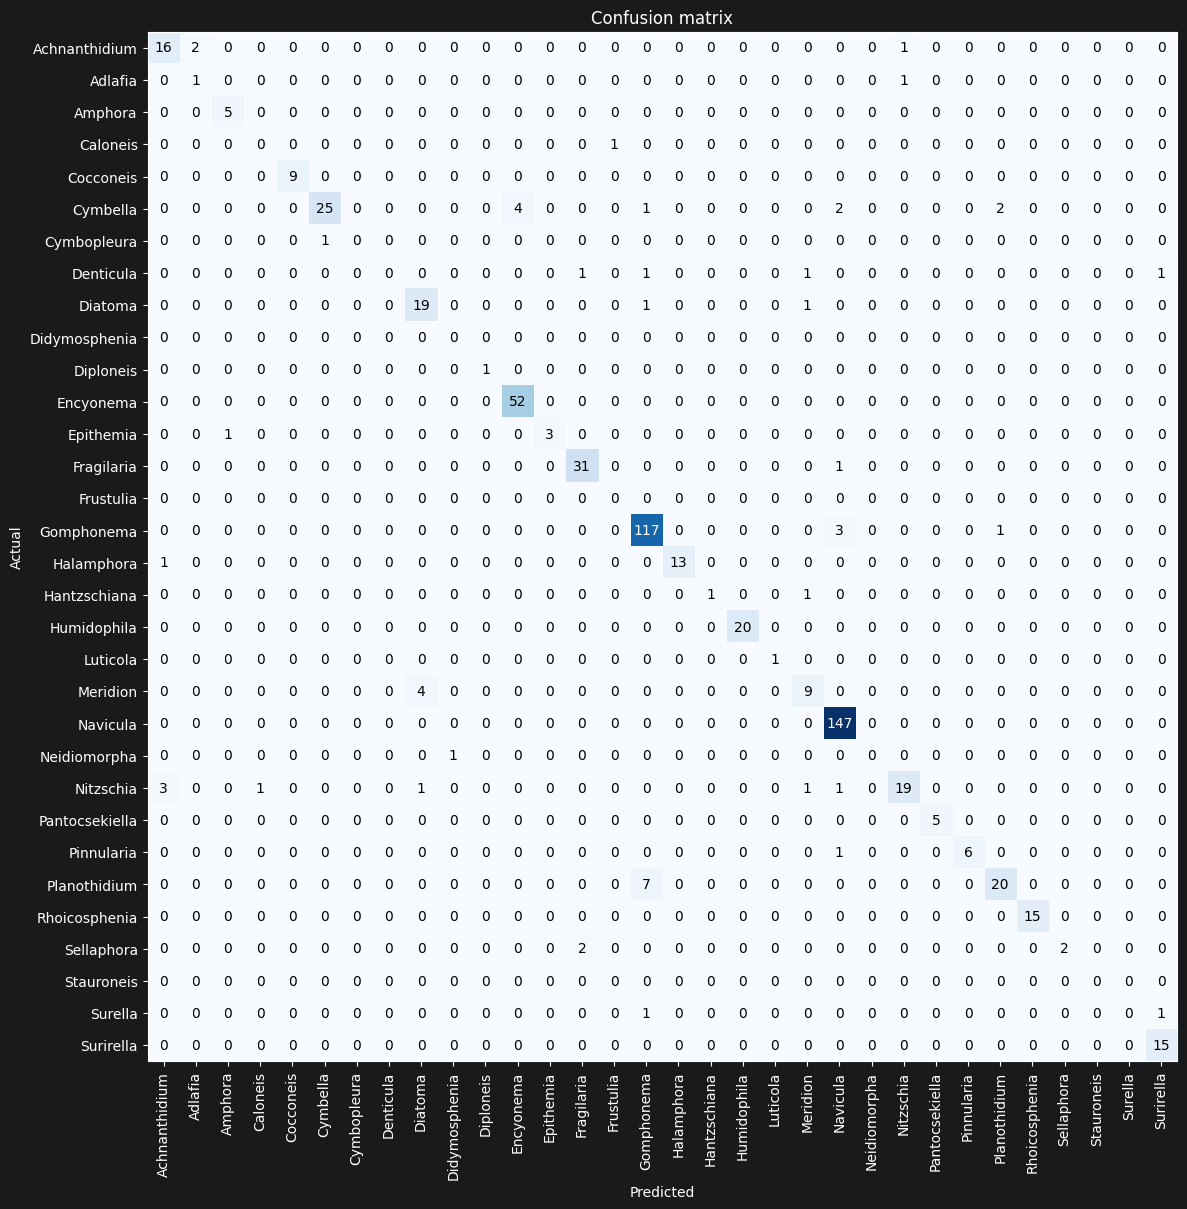

In [17]:
# --- Confusion Matrix ---
# Plotting a large matrix to see exactly which Genera are being confused
interp.plot_confusion_matrix(figsize=(12, 12))

In [18]:
# --- Export for Inference ---
# Save the model weights and architecture to our dedicated models directory
export_path = model_dir / 'baseline_model.pkl'
learn.export(export_path)

print(f"Model successfully saved to {export_path.resolve()}")

Model successfully saved to /home/varfo/PycharmProjects/diatom-classifier/models/baseline_model.pkl
